In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [31]:
ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / "data" / "analysis" / "panel_collapsed.csv")

df["year"] = df["year"].astype(int)
df = df[(df["year"] >= 2000) & (df["year"] <= 2019)].copy()

df.shape

(1453, 14)

In [32]:
trend = (
    df.groupby(["year", "crop"], as_index=False)
      .agg(
          ht_pct=("ht_pct", "mean"),
          ir_pct=("ir_pct", "mean"),
          pesticide_kg_per_ha=("pesticide_kg_per_ha", "mean"),
          yield_bu_per_acre=("yield_bu_per_acre", "mean"),
          erosion_sheet_rill_ton_acre_yr=("erosion_sheet_rill_ton_acre_yr", "mean"),
      )
      .sort_values(["crop", "year"])
)

trend.head()

,year,crop,ht_pct,ir_pct,pesticide_kg_per_ha,yield_bu_per_acre,erosion_sheet_rill_ton_acre_yr
0,2000,corn,6.0,18.0,4.346906,133.190244,NaN
2,2001,corn,7.0,18.0,4.639664,132.375610,NaN
4,2002,corn,9.0,22.0,4.442912,119.107317,2.571463
6,2003,corn,11.0,25.0,4.344690,134.585366,NaN
8,2004,corn,14.0,27.0,4.296065,143.331707,NaN


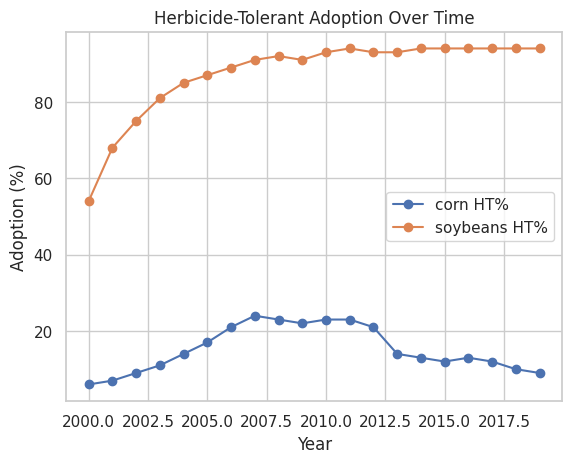

In [33]:
plt.figure()
for crop in sorted(trend["crop"].unique()):
    tmp = trend[trend["crop"] == crop]
    plt.plot(tmp["year"], tmp["ht_pct"], marker="o", label=f"{crop} HT%")

plt.xlabel("Year")
plt.ylabel("Adoption (%)")
plt.title("Herbicide-Tolerant Adoption Over Time")
plt.legend()
plt.show()

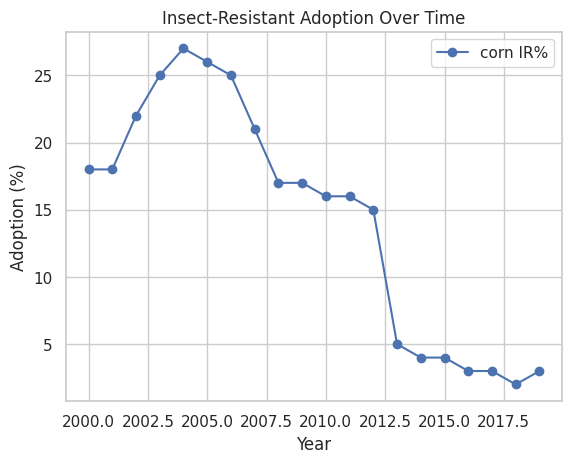

In [34]:
plt.figure()

for crop in sorted(trend["crop"].unique()):
    tmp = trend[(trend["crop"] == crop) & (trend["ir_pct"].notna())]
    if tmp["ir_pct"].sum() == 0:
        continue
    plt.plot(tmp["year"], tmp["ir_pct"], marker="o", label=f"{crop} IR%")

plt.xlabel("Year")
plt.ylabel("Adoption (%)")
plt.title("Insect-Resistant Adoption Over Time")
plt.legend()
plt.show()

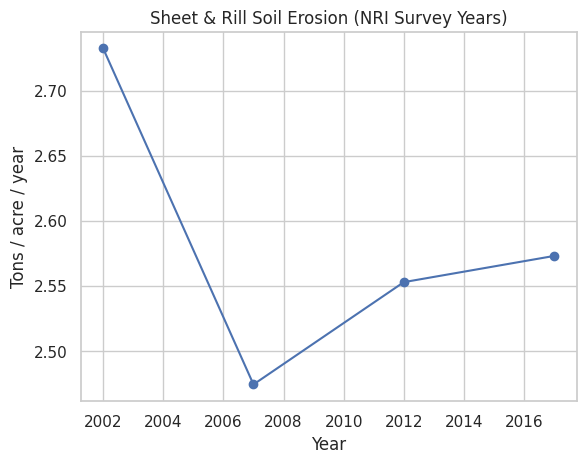

In [35]:
eros = (
    df[df["erosion_sheet_rill_ton_acre_yr"].notna()]
      .groupby("year", as_index=False)["erosion_sheet_rill_ton_acre_yr"]
      .mean()
      .sort_values("year")
)

plt.figure()
plt.plot(
    eros["year"],
    eros["erosion_sheet_rill_ton_acre_yr"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Tons / acre / year")
plt.title("Sheet & Rill Soil Erosion (NRI Survey Years)")
plt.show()

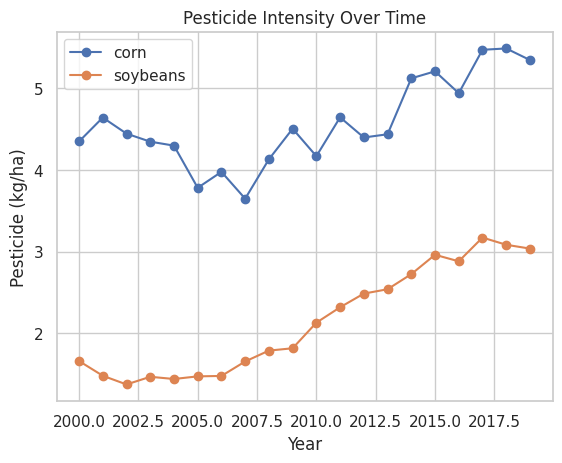

In [36]:
plt.figure()
for crop in sorted(trend["crop"].unique()):
    tmp = trend[trend["crop"] == crop]
    plt.plot(tmp["year"], tmp["pesticide_kg_per_ha"], marker="o", label=crop)

plt.xlabel("Year")
plt.ylabel("Pesticide (kg/ha)")
plt.title("Pesticide Intensity Over Time")
plt.legend()
plt.show()

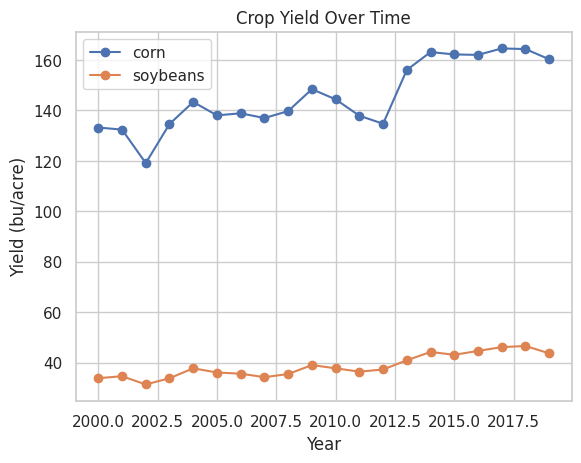

In [37]:
plt.figure()
for crop in sorted(trend["crop"].unique()):
    tmp = trend[trend["crop"] == crop]
    plt.plot(tmp["year"], tmp["yield_bu_per_acre"], marker="o", label=crop)

plt.xlabel("Year")
plt.ylabel("Yield (bu/acre)")
plt.title("Crop Yield Over Time")
plt.legend()
plt.show()

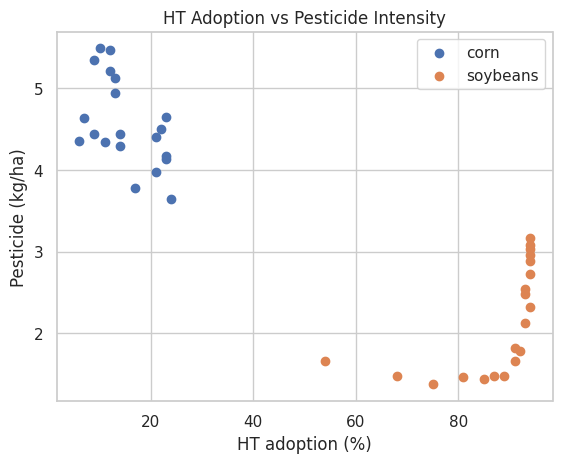

In [39]:
plt.figure()
for crop in sorted(trend["crop"].unique()):
    tmp = trend[trend["crop"] == crop]
    plt.scatter(tmp["ht_pct"], tmp["pesticide_kg_per_ha"], label=crop)

plt.xlabel("HT adoption (%)")
plt.ylabel("Pesticide (kg/ha)")
plt.title("HT Adoption vs Pesticide Intensity")
plt.legend()
plt.show()

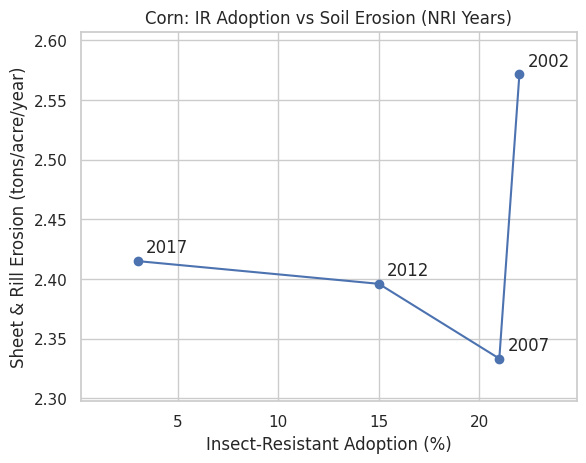

In [ ]:
# Corn-only, NRI erosion years
corn = df[
    (df["crop"] == "corn") &
    (df["erosion_sheet_rill_ton_acre_yr"].notna())
].copy()

corn_nri = (
    corn.groupby("year", as_index=False)
        .agg(
            ir_pct=("ir_pct", "mean"),
            erosion=("erosion_sheet_rill_ton_acre_yr", "mean")
        )
)

corn_nri = corn_nri.sort_values("year").reset_index(drop=True)

corn_nri

plt.figure()

plt.plot(
    corn_nri["ir_pct"],
    corn_nri["erosion"],
    marker="o"
)

for _, r in corn_nri.iterrows():
    plt.annotate(
        str(int(r["year"])),
        (r["ir_pct"], r["erosion"]),
        textcoords="offset points",
        xytext=(6, 6)
    )

plt.xlabel("Insect-Resistant Adoption (%)")
plt.ylabel("Sheet & Rill Erosion (tons/acre/year)")
plt.title("Corn: IR Adoption vs Soil Erosion (NRI Years)")
plt.margins(x=0.15, y=0.15)
plt.show()